In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
torch.manual_seed(42)

In [26]:
df["LogReturn"] = np.log(df["Close"]).diff()
df = df.dropna().reset_index(drop=True)

returns = df["LogReturn"].values.reshape(-1, 1)

In [27]:
split = int(0.8 * len(returns))

train_returns = returns[:split]
test_returns  = returns[split:]

In [28]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_returns)
test_scaled  = scaler.transform(test_returns)

In [ ]:
def make_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])
    return np.array(X), np.array(y)

SEQ_LEN = 30   # deliberately shorter than 60

X_train, y_train = make_sequences(train_scaled, SEQ_LEN)
X_test,  y_test  = make_sequences(test_scaled, SEQ_LEN)

In [42]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

In [43]:
class ReturnLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,   # small = better generalization
            batch_first=True
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [44]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ReturnLSTM().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50
best_val = np.inf
patience = 5
wait = 0

# simple validation split from training data
val_split = int(0.85 * len(X_train))
X_val_t = X_train_t[val_split:].to(device)
y_val_t = y_train_t[val_split:].to(device)

X_train_t2 = X_train_t[:val_split]
y_train_t2 = y_train_t[:val_split]

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in DataLoader(
        TensorDataset(X_train_t2, y_train_t2),
        batch_size=64,
        shuffle=True
    ):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # validation
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()

    if val_loss < best_val:
        best_val = val_loss
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        break

In [45]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t.to(device)).cpu().numpy()

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae_lstm  = mean_absolute_error(y_test_inv, y_pred_inv)

rmse_lstm, mae_lstm

(np.float64(0.0074662754395967345), 0.005320063688222363)

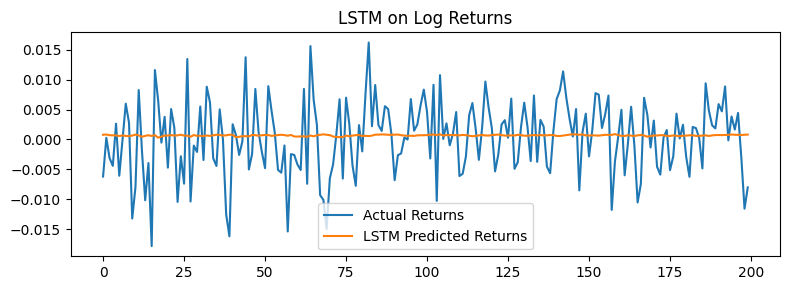

In [46]:
plt.figure(figsize=(8, 3))
plt.plot(y_test_inv[:200], label="Actual Returns")
plt.plot(y_pred_inv[:200], label="LSTM Predicted Returns")
plt.title("LSTM on Log Returns")
plt.legend()
plt.tight_layout()
plt.show()